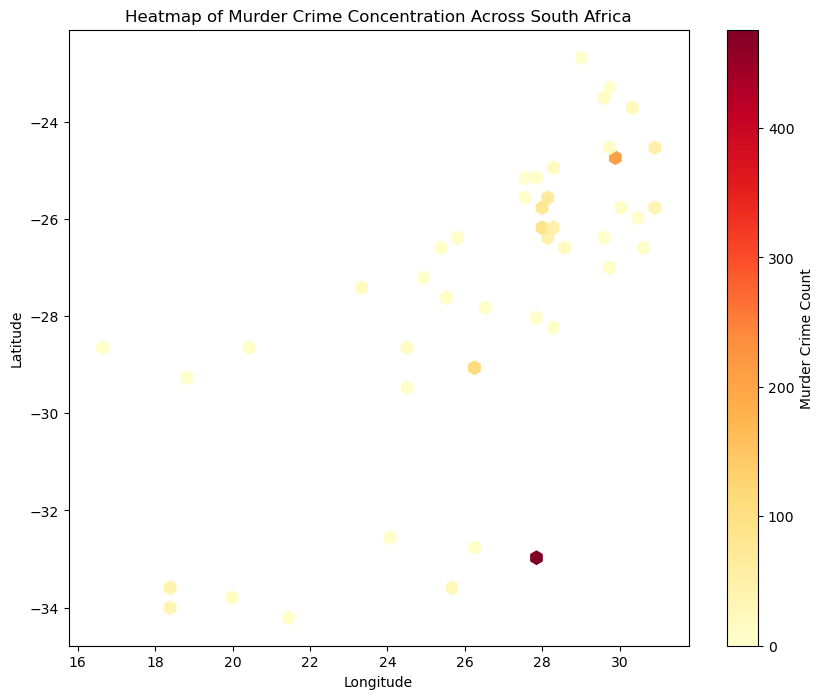

ValueError: 'Y' is not a valid value for cmap; supported values are 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'cool

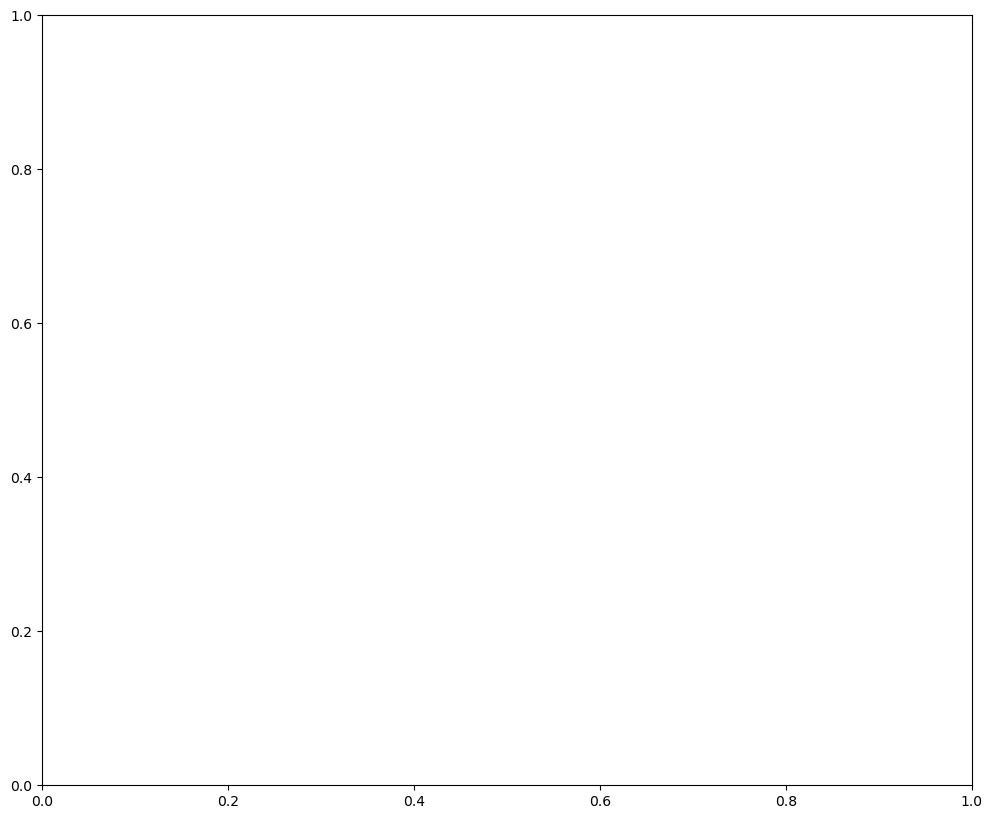

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

# Load the cleaned dataset
file_path = 'Book4clean.csv'
data_2 = pd.read_csv(file_path)

# Clean the dataset by renaming columns and dropping unnecessary ones
data_2_cleaned = data_2.rename(columns={
    'province': 'Province',
    'longtitude': 'Longitude',
    'latitute': 'Latitude',
    'district': 'District'
})

# Drop the 'Unnamed: 36' column as it appears irrelevant
data_2_cleaned = data_2_cleaned.drop(columns=['Unnamed: 36'])

# Convert crime columns to numeric values, coercing any errors (non-numeric values) to NaN
crime_columns = ['Murder', 'Sexual offences', 'Attempted murder', 'Assault with the intent to inflict grievous bodily harm', 
                 'Common assault', 'Common robbery', 'Burglary at residential premises', 'Burglary at non-residential premises', 
                 'Theft of motor vehicle and motorcycle', 'Theft out of or from motor vehicle', 'Stock-theft', 
                 'All theft not mentioned elsewhere', 'Commercial crime', 'Shoplifting', 'Illegal possession of firearms and ammunition', 
                 'Drug-related crime', 'Driving under the influence of alcohol or drugs', 
                 'Sexual offences detected as a result of police action', 'Kidnapping']

# Convert the columns to numeric values, forcing non-numeric data to NaN
for column in crime_columns:
    data_2_cleaned[column] = pd.to_numeric(data_2_cleaned[column], errors='coerce')

# Approach 1: Heatmap for Crime Concentration
# Generate the heatmap for the selected crime (e.g., 'Murder')
plt.figure(figsize=(10, 8))
plt.hexbin(data_2_cleaned['Longitude'], data_2_cleaned['Latitude'], C=data_2_cleaned['Murder'], gridsize=50, cmap='YlOrRd', mincnt=1)
plt.colorbar(label='Murder Crime Count')
plt.title('Heatmap of Murder Crime Concentration Across South Africa')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Approach 2: Bubble Map for Crime Concentration
# Generate a bubble map for 'Murder' crime concentration
plt.figure(figsize=(12, 10))

# Plot bubbles for crime data (e.g., 'Murder') based on latitude and longitude
plt.scatter(data_2_cleaned['Longitude'], data_2_cleaned['Latitude'], 
            s=data_2_cleaned['Murder'] / 10,  # Size of bubble based on 'Murder' count
            c=data_2_cleaned['Murder'], cmap='Y')


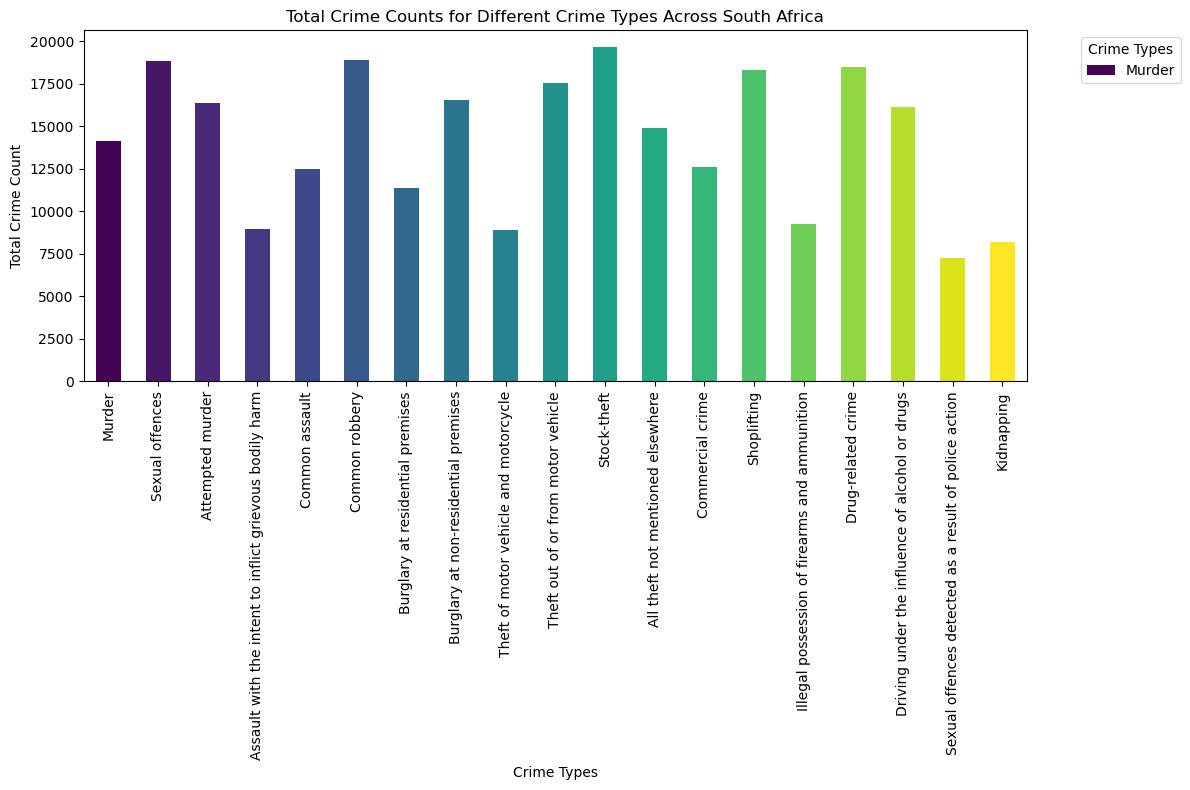

In [3]:

# Convert the columns to numeric values, forcing non-numeric data to NaN
for column in crime_columns:
    data_2_cleaned[column] = pd.to_numeric(data_2_cleaned[column], errors='coerce')

# Summing up the total crime counts for each crime type
total_crimes = data_2_cleaned[crime_columns].sum()

# Create a bar chart
plt.figure(figsize=(12, 8))
total_crimes.plot(kind='bar', color=plt.cm.viridis(np.linspace(0, 1, len(total_crimes))))

# Add title and labels
plt.title('Total Crime Counts for Different Crime Types Across South Africa')
plt.xlabel('Crime Types')
plt.ylabel('Total Crime Count')

# Rotate the x-axis labels for better readability
plt.xticks(rotation=90)

# Add a key (legend) for the colors
plt.legend(total_crimes.index, title="Crime Types", bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()

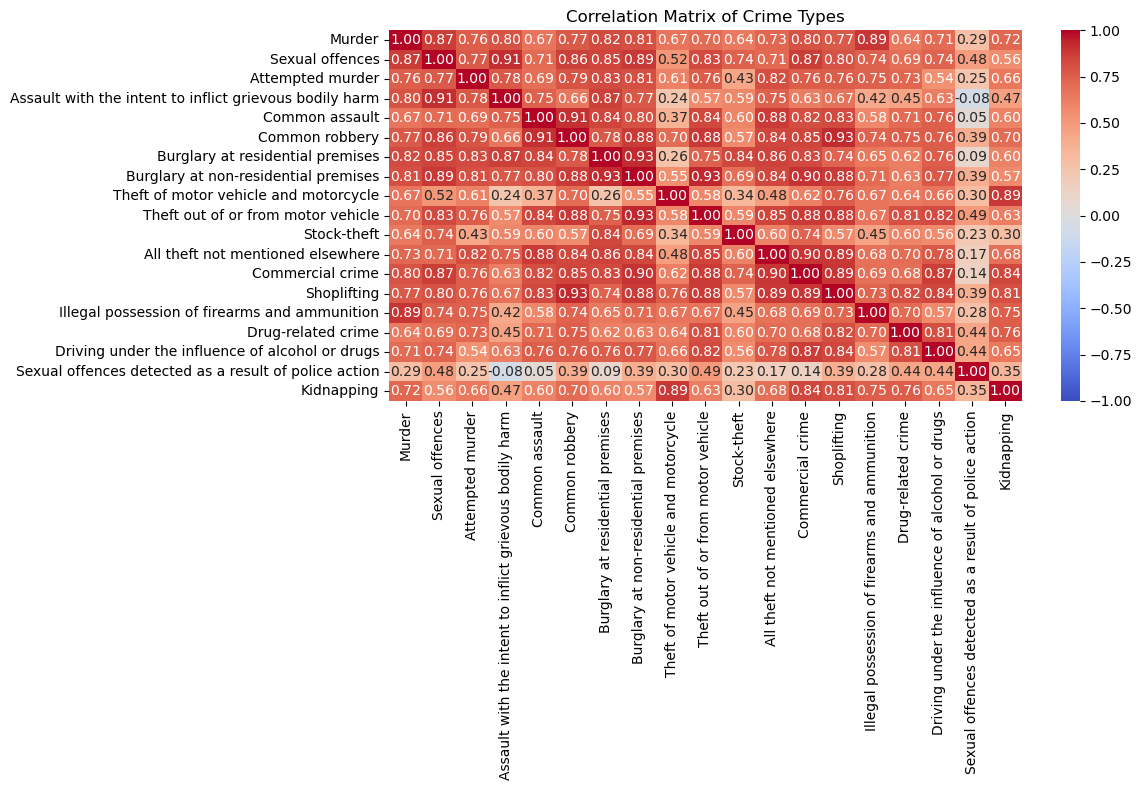

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the cleaned dataset
file_path = 'Book4clean.csv'
data_2 = pd.read_csv(file_path)

# Clean the dataset by renaming columns and dropping unnecessary ones
data_2_cleaned = data_2.rename(columns={
    'province': 'Province',
    'longtitude': 'Longitude',
    'latitute': 'Latitude',
    'district': 'District'
})

# Drop the 'Unnamed: 36' column as it appears irrelevant
data_2_cleaned = data_2_cleaned.drop(columns=['Unnamed: 36'])

# Convert crime columns to numeric values, coercing any errors (non-numeric values) to NaN
crime_columns = ['Murder', 'Sexual offences', 'Attempted murder', 'Assault with the intent to inflict grievous bodily harm', 
                 'Common assault', 'Common robbery', 'Burglary at residential premises', 'Burglary at non-residential premises', 
                 'Theft of motor vehicle and motorcycle', 'Theft out of or from motor vehicle', 'Stock-theft', 
                 'All theft not mentioned elsewhere', 'Commercial crime', 'Shoplifting', 'Illegal possession of firearms and ammunition', 
                 'Drug-related crime', 'Driving under the influence of alcohol or drugs', 
                 'Sexual offences detected as a result of police action', 'Kidnapping']

# Convert the columns to numeric values, forcing non-numeric data to NaN
for column in crime_columns:
    data_2_cleaned[column] = pd.to_numeric(data_2_cleaned[column], errors='coerce')

# Correlation matrix for crime types
crime_correlation = data_2_cleaned[crime_columns].corr()

# Plot correlation matrix heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(crime_correlation, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Crime Types')
plt.tight_layout()
plt.show()


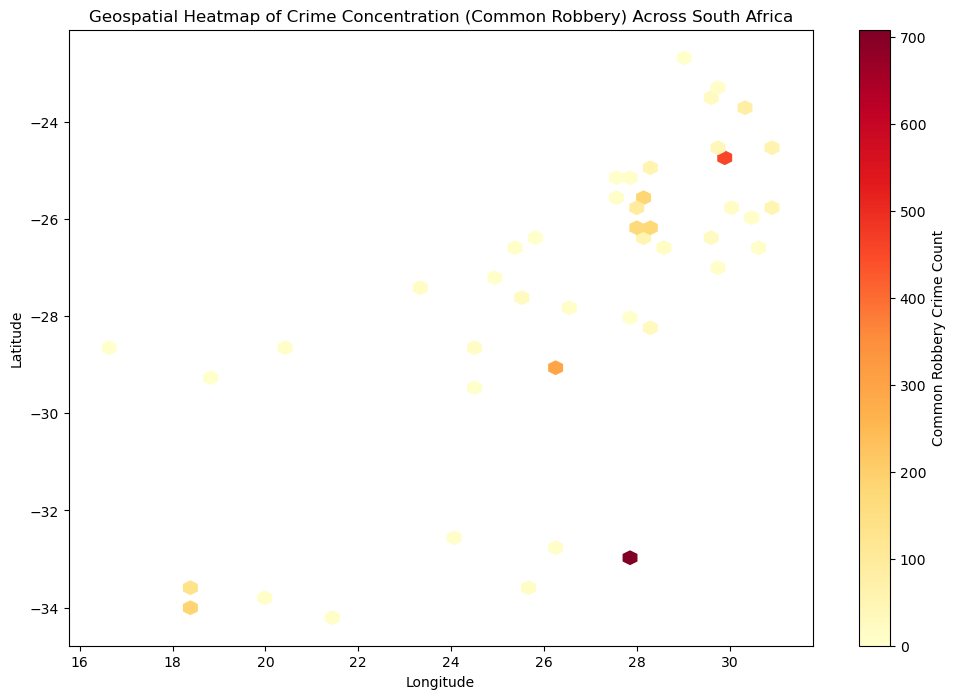

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure the dataset has no missing latitude and longitude values
data_for_heatmap = data_2_cleaned.dropna(subset=['Longitude', 'Latitude'])

# Generate the geospatial heatmap using hexbin
plt.figure(figsize=(12, 8))
plt.hexbin(data_for_heatmap['Longitude'], data_for_heatmap['Latitude'], 
           C=data_for_heatmap['Common robbery'], gridsize=50, cmap='YlOrRd', mincnt=1)
plt.colorbar(label='Common Robbery Crime Count')
plt.title('Geospatial Heatmap of Crime Concentration (Common Robbery) Across South Africa')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


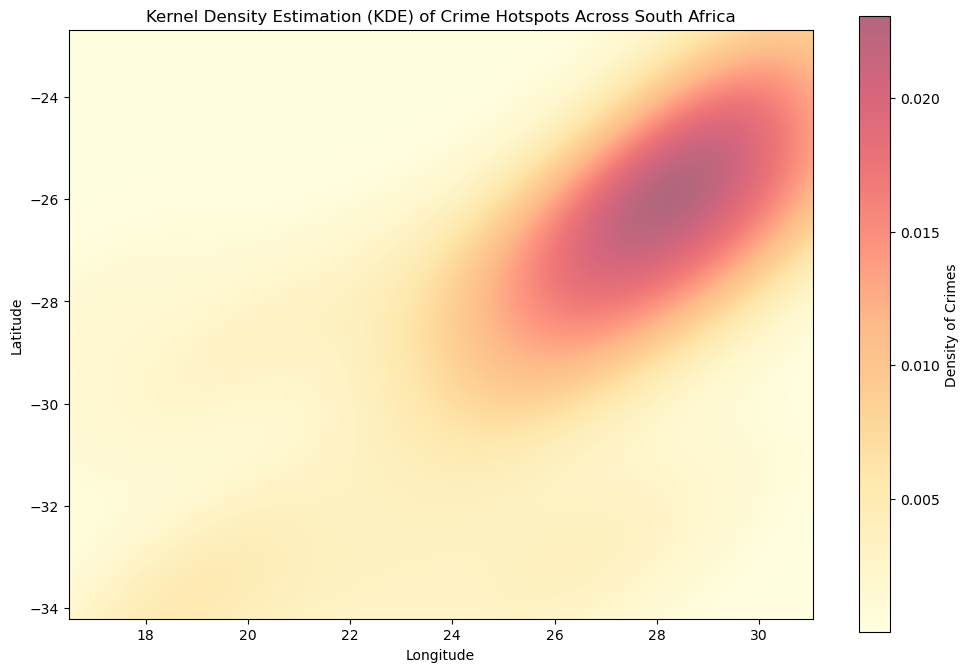

In [8]:
import geopandas as gpd
from shapely.geometry import Point
from scipy.stats import gaussian_kde

# Ensure the dataset has no missing latitude and longitude values
data_for_kde = data_2_cleaned.dropna(subset=['Longitude', 'Latitude'])

# Create GeoDataFrame with Latitude and Longitude as geometry
geometry = [Point(xy) for xy in zip(data_for_kde['Longitude'], data_for_kde['Latitude'])]
geo_data = gpd.GeoDataFrame(data_for_kde, geometry=geometry)

# Perform Kernel Density Estimation (KDE) to visualize crime hotspots
x = np.array(geo_data['Longitude'])
y = np.array(geo_data['Latitude'])

# Perform KDE
kde = gaussian_kde([x, y], bw_method='silverman')

# Create a grid of points
xgrid = np.linspace(min(x), max(x), 500)
ygrid = np.linspace(min(y), max(y), 500)
X, Y = np.meshgrid(xgrid, ygrid)
positions = np.vstack([X.ravel(), Y.ravel()])
Z = np.reshape(kde(positions).T, X.shape)

# Plot the result
plt.figure(figsize=(12, 8))
plt.imshow(Z, extent=(min(x), max(x), min(y), max(y)), origin='lower', cmap='YlOrRd', alpha=0.6)
plt.colorbar(label='Density of Crimes')
plt.title('Kernel Density Estimation (KDE) of Crime Hotspots Across South Africa')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


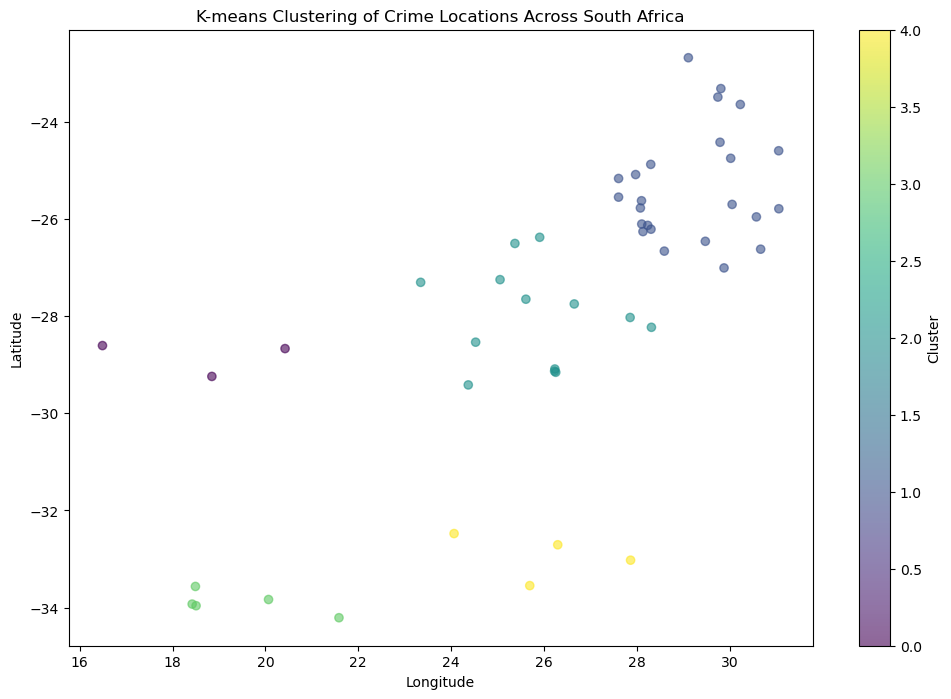

In [9]:
from sklearn.cluster import KMeans

# Prepare the data for clustering (only using Longitude and Latitude)
crime_data = data_2_cleaned.dropna(subset=['Longitude', 'Latitude'])[['Longitude', 'Latitude']]

# Set the number of clusters (you can adjust this)
kmeans = KMeans(n_clusters=5)
crime_data['Cluster'] = kmeans.fit_predict(crime_data[['Longitude', 'Latitude']])

# Plot the clusters
plt.figure(figsize=(12, 8))
plt.scatter(crime_data['Longitude'], crime_data['Latitude'], c=crime_data['Cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Cluster')
plt.title('K-means Clustering of Crime Locations Across South Africa')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


/var/folders/cc/8bj2xc152k5dq8s67469d59m0000gn/T/ipykernel_62395/99672626.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  crime_colors = plt.cm.get_cmap("tab20", len(crime_columns))


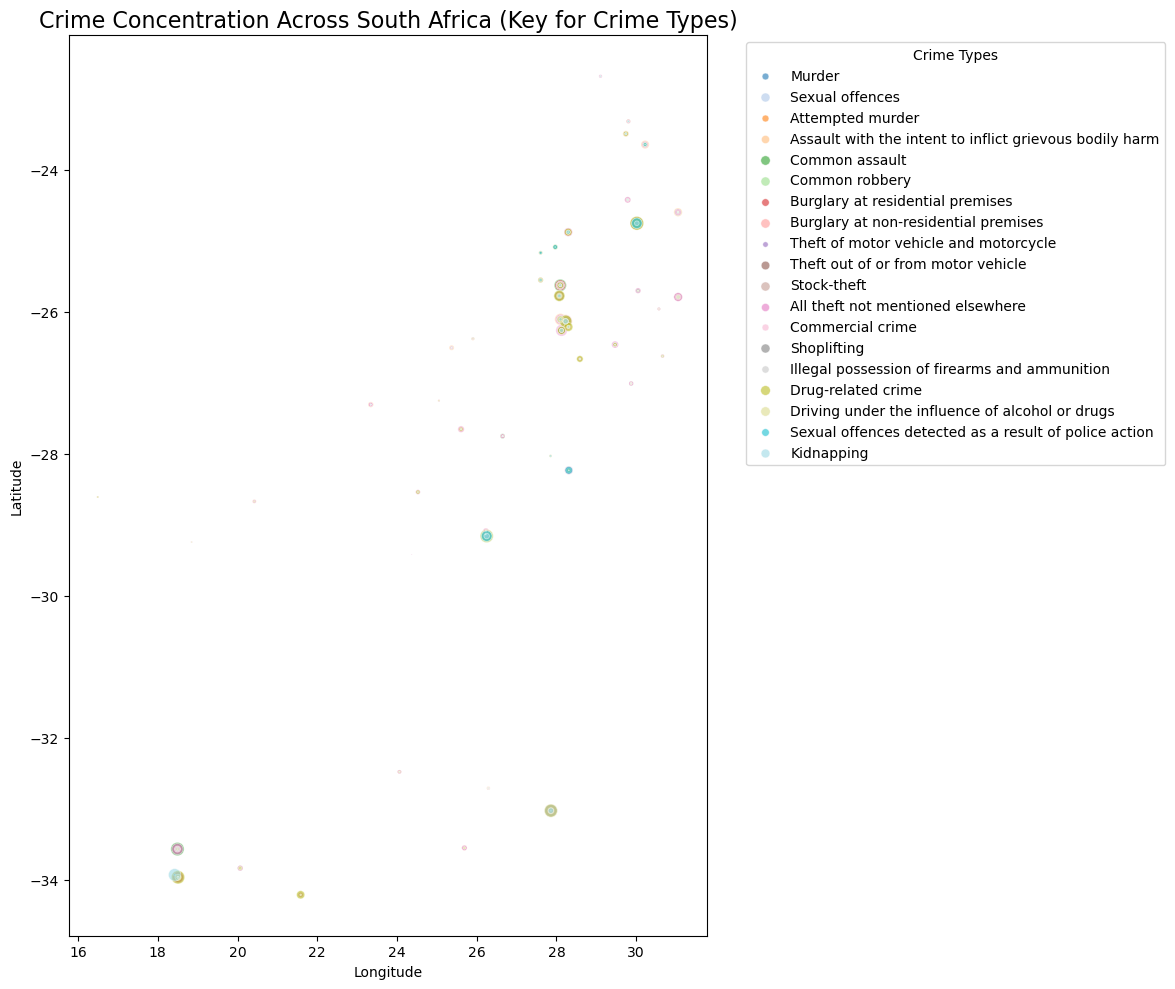

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'data_cleaned' is the cleaned DataFrame containing the crime data with Latitude, Longitude, and Crime columns

# List of crime columns to plot
crime_columns = ['Murder', 'Sexual offences', 'Attempted murder', 'Assault with the intent to inflict grievous bodily harm', 
                 'Common assault', 'Common robbery', 'Burglary at residential premises', 'Burglary at non-residential premises', 
                 'Theft of motor vehicle and motorcycle', 'Theft out of or from motor vehicle', 'Stock-theft', 
                 'All theft not mentioned elsewhere', 'Commercial crime', 'Shoplifting', 'Illegal possession of firearms and ammunition', 
                 'Drug-related crime', 'Driving under the influence of alcohol or drugs', 
                 'Sexual offences detected as a result of police action', 'Kidnapping']

# Define a color map for the different crime types
crime_colors = plt.cm.get_cmap("tab20", len(crime_columns))

# Plotting each crime type with a different color
plt.figure(figsize=(12, 10))

for idx, crime in enumerate(crime_columns):
    crime_data = data_2_cleaned.dropna(subset=['Longitude', 'Latitude', crime])
    plt.scatter(crime_data['Longitude'], crime_data['Latitude'], 
                s=crime_data[crime] / 10,  # Adjust the size of the bubble based on crime count
                c=[crime_colors(idx)], label=crime, alpha=0.6, edgecolors="w", linewidth=0.5)

# Add a title and labels
plt.title('Crime Concentration Across South Africa (Key for Crime Types)', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Add a legend for each crime type
plt.legend(title="Crime Types", bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()


In [27]:
import geopandas as gpd
from shapely.geometry import Point

# Assuming you have geographic boundaries (e.g., shapefiles for districts or provinces)
# You can use GeoPandas to read shapefiles and merge with your crime data

# Example: Create GeoDataFrame from the cleaned data
geometry = [Point(xy) for xy in zip(data_2_cleaned['Longitude'], data_2_cleaned['Latitude'])]
geo_data = gpd.GeoDataFrame(data_2_cleaned, geometry=geometry)

# Load the shapefile for South Africa's districts or provinces (replace with your file)
shapefile = gpd.read_file('station_boundaries_points/station_points/Police_points.shp')

# Merge your crime data with the shapefile based on geographic identifiers (e.g., district names)
#merged_data = shapefile.merge(geo_data, on='district')

# Plotting the choropleth map
# merged_data.plot(column='Total_Crime', cmap='YlOrRd', legend=True, figsize=(12, 8), legend_kwds={'label': "Total Crime by District"})
# plt.title('Choropleth Map of Crime Concentration by District')
# plt.show()

shapefile.to_csv('shapefile.csv', index=False)


   province  longtitude  latitute       district Murder Sexual offences  \
2       NaN    27.86027 -33.02401  Buffalo city     476           1,159   
6       NaN    28.22985 -26.13293          Tambo  1,178           1,672   
8       NaN    24.06098 -32.47634       aberdeen      4              14   
9       NaN    25.69029 -33.54769           addo     25              31   
10      NaN    26.29255 -32.70725       Adeleide      4              16   

   Attempted murder Assault with the intent to inflict grievous bodily harm  \
2               238                                              4,638        
6               484                                              3,644        
8                 2                                                 66        
9                21                                                150        
10                8                                                 61        

   Common assault Common robbery  ... Unnamed: 36                  geometr

TypeError: Legend.__init__() got an unexpected keyword argument 'label'

<Figure size 1200x1000 with 0 Axes>

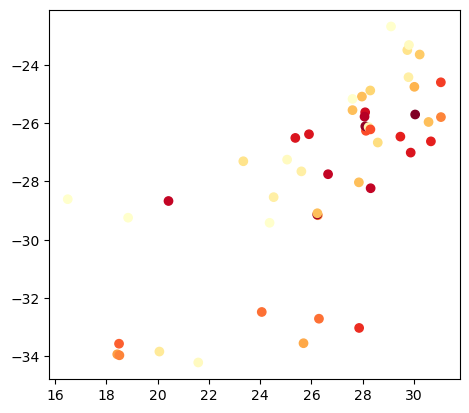

In [35]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# Load the crime data (CSV) and shapefile data (CSV) to inspect the content
crime_data_path = 'Book4clean.csv'
shapefile_data_path = 'shapefile.csv'

# Load both CSV files
crime_data = pd.read_csv(crime_data_path)
shapefile_data = pd.read_csv(shapefile_data_path)

# Clean crime data by removing rows with missing longitude or latitude
crime_data_cleaned = crime_data.dropna(subset=['longtitude', 'latitute'])

# Ensure the crime data has valid coordinates
crime_data_cleaned = crime_data_cleaned[crime_data_cleaned['longtitude'].apply(lambda x: pd.to_numeric(x, errors='coerce')).notna()]
crime_data_cleaned = crime_data_cleaned[crime_data_cleaned['latitute'].apply(lambda x: pd.to_numeric(x, errors='coerce')).notna()]

# Create a GeoDataFrame for crime data using longitude and latitude from crime data
geometry = [Point(xy) for xy in zip(crime_data_cleaned['longtitude'], crime_data_cleaned['latitute'])]
crime_geo_data = gpd.GeoDataFrame(crime_data_cleaned, geometry=geometry)

# Create a GeoDataFrame for the shapefile points (from the shapefile data)
shapefile_geometry = [Point(xy) for xy in zip(shapefile_data['LOCATION_X'], shapefile_data['LOCATION_Y'])]
shapefile_geo_data = gpd.GeoDataFrame(shapefile_data, geometry=shapefile_geometry)

# Set CRS for both GeoDataFrames (assuming EPSG:4326 for latitude/longitude)
crime_geo_data.set_crs("EPSG:4326", inplace=True)
shapefile_geo_data.set_crs("EPSG:4326", inplace=True)

# Step 1: Convert shapefile points to an array of coordinates
shapefile_coords = list(zip(shapefile_geo_data.geometry.x, shapefile_geo_data.geometry.y))

# Step 2: Create a cKDTree from shapefile coordinates for efficient nearest neighbor search
kdtree = cKDTree(shapefile_coords)

# Step 3: For each crime point, find the nearest shapefile point
crime_coords = list(zip(crime_geo_data.geometry.x, crime_geo_data.geometry.y))
distances, indices = kdtree.query(crime_coords, k=1)

# Step 4: Add the nearest shapefile point information to the crime GeoDataFrame
crime_geo_data['nearest_shapefile_idx'] = indices
crime_geo_data['distance_to_nearest'] = distances

# Step 5: Merge the nearest shapefile point information with crime data
crime_merged = crime_geo_data.merge(shapefile_geo_data, left_on='nearest_shapefile_idx', right_index=True)

# Inspect the merged data
print(crime_merged.head())

# Step 6: Aggregating crime data by district or location (using COMPNT_NM)
crime_aggregated = crime_merged.groupby('COMPNT_NM').agg({'Murder': 'sum', 'Sexual offences': 'sum'}).reset_index()

# Merge the aggregated crime data with the shapefile data (districts)
crime_aggregated_shapefile = shapefile_geo_data.merge(crime_aggregated, left_on='COMPNT_NM', right_on='COMPNT_NM')

# Plotting the choropleth map
plt.figure(figsize=(12, 10))
crime_aggregated_shapefile.plot(column='Murder', cmap='YlOrRd', legend=True,
                                legend_kwds={'label': "Total Murder Crimes by District"})
plt.title('Choropleth Map of Murder Crime Concentration by District')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


   province  longtitude  latitute       district Murder Sexual offences  \
2       NaN    27.86027 -33.02401  Buffalo city     476           1,159   
6       NaN    28.22985 -26.13293          Tambo  1,178           1,672   
8       NaN    24.06098 -32.47634       aberdeen      4              14   
9       NaN    25.69029 -33.54769           addo     25              31   
10      NaN    26.29255 -32.70725       Adeleide      4              16   

   Attempted murder Assault with the intent to inflict grievous bodily harm  \
2               238                                              4,638        
6               484                                              3,644        
8                 2                                                 66        
9                21                                                150        
10                8                                                 61        

   Common assault Common robbery  ... Unnamed: 36                  geometr

<Figure size 1200x1000 with 0 Axes>

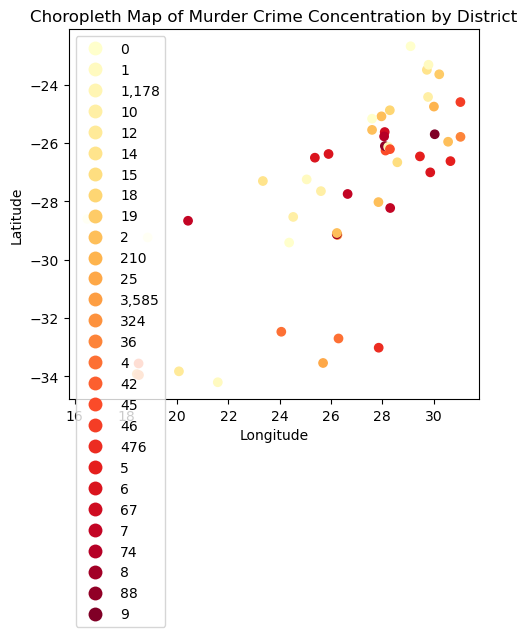

In [36]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# Load the crime data (CSV) and shapefile data (CSV)
crime_data_path = 'Book4clean.csv'
shapefile_data_path = 'shapefile.csv'

# Load both CSV files
crime_data = pd.read_csv(crime_data_path)
shapefile_data = pd.read_csv(shapefile_data_path)

# Clean crime data by removing rows with missing longitude or latitude
crime_data_cleaned = crime_data.dropna(subset=['longtitude', 'latitute'])

# Ensure the crime data has valid coordinates
crime_data_cleaned = crime_data_cleaned[crime_data_cleaned['longtitude'].apply(lambda x: pd.to_numeric(x, errors='coerce')).notna()]
crime_data_cleaned = crime_data_cleaned[crime_data_cleaned['latitute'].apply(lambda x: pd.to_numeric(x, errors='coerce')).notna()]

# Create a GeoDataFrame for crime data using longitude and latitude from crime data
geometry = [Point(xy) for xy in zip(crime_data_cleaned['longtitude'], crime_data_cleaned['latitute'])]
crime_geo_data = gpd.GeoDataFrame(crime_data_cleaned, geometry=geometry)

# Create a GeoDataFrame for the shapefile points (from the shapefile data)
shapefile_geometry = [Point(xy) for xy in zip(shapefile_data['LOCATION_X'], shapefile_data['LOCATION_Y'])]
shapefile_geo_data = gpd.GeoDataFrame(shapefile_data, geometry=shapefile_geometry)

# Set CRS for both GeoDataFrames (assuming EPSG:4326 for latitude/longitude)
crime_geo_data.set_crs("EPSG:4326", inplace=True)
shapefile_geo_data.set_crs("EPSG:4326", inplace=True)

# Step 1: Convert shapefile points to an array of coordinates
shapefile_coords = list(zip(shapefile_geo_data.geometry.x, shapefile_geo_data.geometry.y))

# Step 2: Create a cKDTree from shapefile coordinates for efficient nearest neighbor search
kdtree = cKDTree(shapefile_coords)

# Step 3: For each crime point, find the nearest shapefile point
crime_coords = list(zip(crime_geo_data.geometry.x, crime_geo_data.geometry.y))
distances, indices = kdtree.query(crime_coords, k=1)

# Step 4: Add the nearest shapefile point information to the crime GeoDataFrame
crime_geo_data['nearest_shapefile_idx'] = indices
crime_geo_data['distance_to_nearest'] = distances

# Step 5: Merge the nearest shapefile point information with crime data
crime_merged = crime_geo_data.merge(shapefile_geo_data, left_on='nearest_shapefile_idx', right_index=True)

# Inspect the merged data
print(crime_merged.head())

# Step 6: Aggregating crime data by district or location (using COMPNT_NM)
crime_aggregated = crime_merged.groupby('COMPNT_NM').agg({'Murder': 'sum', 'Sexual offences': 'sum'}).reset_index()

# Merge the aggregated crime data with the shapefile data (districts)
crime_aggregated_shapefile = shapefile_geo_data.merge(crime_aggregated, left_on='COMPNT_NM', right_on='COMPNT_NM')

# Plotting the choropleth map
plt.figure(figsize=(12, 10))
crime_aggregated_shapefile.plot(column='Murder', cmap='YlOrRd', legend=True)
plt.title('Choropleth Map of Murder Crime Concentration by District')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()
